In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

dataset_path = "/content/drive/MyDrive/data_dechet/Data/Train"

print(os.listdir(dataset_path))

['plastic', 'metal']


In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(300,300),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 629 images belonging to 2 classes.
Found 157 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)
print(val_data.class_indices)

{'metal': 0, 'plastic': 1}
{'metal': 0, 'plastic': 1}


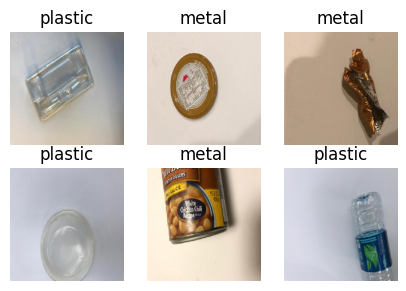

In [ ]:
# Prendre un batch d'images
images, labels = next(train_data)
plt.figure(figsize=(5,5))
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[labels[i].argmax()])
    plt.axis('off')
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    brightness_range=(0.6, 1.4),
    horizontal_flip=True
)

In [ ]:

model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='same', input_shape=(300,300,3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))

model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [ ]:
history=model.fit(
    train_data,
    epochs=8,
    batch_size=32,
    validation_data=val_data
)

Epoch 1/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.5994 - loss: 0.7211 - val_accuracy: 0.6497 - val_loss: 0.6561
Epoch 2/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.7313 - loss: 0.5271 - val_accuracy: 0.7325 - val_loss: 0.5785
Epoch 3/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.7711 - loss: 0.4749 - val_accuracy: 0.7389 - val_loss: 0.6158
Epoch 4/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - accuracy: 0.7997 - loss: 0.4468 - val_accuracy: 0.7389 - val_loss: 0.6092
Epoch 5/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.8219 - loss: 0.4163 - val_accuracy: 0.7580 - val_loss: 0.6310
Epoch 6/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.8410 - loss: 0.3617 - val_accuracy: 0.7580 - val_loss: 0.5855
Epoch 7/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.8331 - loss: 0.3309 - val_accuracy: 0.7643 - val_loss: 0.6597
Epoch 8/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.8680 - loss: 0.3063 - val_accuracy: 0.7707 - va

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Optimisation
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/drive/MyDrive/model_dechetAI.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpv1mskntz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor_79')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135983961307472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911834960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911836880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911835728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911834000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911836496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911837648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911835920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911837072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135983911833232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13598391183

In [ ]:
model.save('model_dechetAID.h5')

In [ ]:
classes=['plastique','papier']

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Prendre photo';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

In [ ]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    confidence = np.max(prediction)
    classe = np.argmax(prediction)

    if confidence < 0.7:
        print("AUTRE (objet inconnu)")
    else:
        print(f"Classe: {classes[classe]} ({confidence*100:.2f}%)")

In [ ]:
photo=take_photo()
predict_image(photo)

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
Classe: plastique (81.62%)
